# Reasoning Driving · `playground.ipynb`

**EGN 6216 AI Systems · Data collection stage (groundwork for Milestone 3)**

This notebook downloads the project data from its sources, loads it into tables and checks its quality.
The project asks a multimodal GPT model what a lane marking means in China and in the US, with and without the local rule text, so it needs three kinds of data:

| Source | What it is | Where it lives | How it gets here |
|---|---|---|---|
| **CULane** (China) | Dash-camera frames from Beijing, 1640×590, lane positions | Authors' official Google Drive | **Downloaded by hand in the browser** (Google Drive blocked the scripted `gdown` download); the notebook checks and unpacks the archives |
| **BDD100K** (US) | Dash-camera frames from US cities, 1280×720, lane categories and scene tags | Official server; Dataset Ninja mirror when it is down | Downloaded by the notebook (HTTP with resume) |
| **MUTCD** (US rules) | MUTCD 11th Ed. Part 3, Markings | FHWA website | Downloaded by the notebook |
| **GB 5768.3** (China rules) | GB 5768.3-2025, Part 3, Road traffic markings | National standards platform | **Saved by hand from the official site** (no direct download link); the notebook checks the file |

**Two manual steps** before the first run (details in Sections 2 and 3):

1. Put the five CULane archives into `data/raw/culane/`.
2. Put `GB_5768.3-2025.pdf` into `data/raw/rules/`.

Everything else is downloaded automatically. If a manual file is missing, the notebook stops and says which file to get and where to put it.

**Sections:** 0 Setup · 1–3 Retrieve · 4 Load · 5 Size, fields, types · 6 Real examples · 7 Data checks · 8 Rule corpus · 9 Findings and gaps · 10 Changes since Milestone 2

> Run with **Kernel → Restart Kernel and Run All Cells**. The first run downloads about 20 GB; later runs reuse the files in `data/` (ignored by Git, so no dataset file is in this repository).
> The repository is public. The few dataset images shown below are only there to inspect the data; CULane and BDD100K are licensed for non-commercial research, and the images show people and licence plates, so faces and plates will be blurred before an image is used in a report.

## 0 · Setup

Imports, paths and fixed settings for the whole notebook.

* The data folder is `data/` next to this notebook, or `DATA_DIR` from `.env` if the data is kept somewhere else. The cell stops if that drive is not connected, so a missing disk does not look like a missing dataset.
* Python and package versions are printed so the run can be repeated with the same setup.
* A fixed random seed (6216) makes the samples in Sections 6 and 7 the same on every run.
* The second cell holds small helper functions: download with resume, unpack zip/tar archives (skipping macOS `._` files and renaming files the exFAT drive cannot store), and `record()`, which writes each file's origin, size, date and license to `data_manifest.csv`.

In [1]:
import hashlib, json, os, platform, random, sys, tarfile, time, zipfile
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from PIL import Image
from dotenv import load_dotenv
from IPython.display import display, Markdown

# paths (run the notebook from the repository folder)
REPO = Path.cwd()
assert (REPO / "config" / "data_sources.json").exists(), "Open the notebook from the repository root folder."

load_dotenv(REPO / ".env")                      # optional: DATA_DIR
DATA_DIR = Path(os.getenv("DATA_DIR") or REPO / "data").expanduser().resolve()
if not DATA_DIR.parent.exists():                # external drive not connected
    raise FileNotFoundError(f"{DATA_DIR.parent} does not exist. Is the external drive connected? (DATA_DIR is set in .env)")
RAW = DATA_DIR / "raw"                          # downloaded archives
EXTRACTED = DATA_DIR / "extracted"              # unpacked files
for p in (RAW / "bdd100k", RAW / "culane", RAW / "rules", EXTRACTED / "bdd100k", EXTRACTED / "culane"):
    p.mkdir(parents=True, exist_ok=True)

SOURCES = json.loads((REPO / "config" / "data_sources.json").read_text(encoding="utf-8"))

# settings
OFFLINE = os.getenv("RM_OFFLINE", "0") == "1"   # only use files already in data/raw
GET_BDD_TRAIN_IMAGES = False                    # also use the 70k train images (more candidates)
SEED = 6216                                     # fixed seed for all random samples
random.seed(SEED); np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 80, "axes.titlesize": 9})
try:                                            # JPEG figures keep the notebook file small
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("jpeg")
except ImportError:
    pass

# environment info (for requirements.txt / Docker later)
print(f"Python     : {sys.version.split()[0]}  ({platform.system()} {platform.release()})")
for mod in (pd, np, matplotlib, requests):
    print(f"{mod.__name__:<11}: {mod.__version__}")
print(f"{'Pillow':<11}: {Image.__version__}")
print(f"Repository : {REPO}")
print(f"Data folder: {DATA_DIR}")
print(f"Offline    : {OFFLINE}")

Python     : 3.11.17  (Darwin 25.2.0)
pandas     : 2.2.3
numpy      : 2.1.3
matplotlib : 3.9.2
requests   : 2.32.3
Pillow     : 11.0.0
Repository : /Volumes/T9/Project/Reasning_Drive
Data folder: /Volumes/T9/Project/Reasning_Drive/data
Offline    : False


In [2]:
# helper functions for downloading and unpacking
def human(n):
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} PB"

def md5_of(path, chunk=8 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def write_meta(dest, origin):
    """Save source URL and download date next to the file (used for data_manifest.csv)."""
    meta = {"origin": origin, "retrieved_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d")}
    Path(str(dest) + ".meta.json").write_text(json.dumps(meta), encoding="utf-8")

def read_meta(dest, default_origin):
    m = Path(str(dest) + ".meta.json")
    if m.exists():
        return json.loads(m.read_text(encoding="utf-8"))
    # file was copied in by hand: use its modified date
    date = datetime.fromtimestamp(Path(dest).stat().st_mtime, timezone.utc).strftime("%Y-%m-%d")
    return {"origin": default_origin, "retrieved_utc": date}

def fetch_md5(url):
    """Get the published .md5 checksum if the server has one."""
    if OFFLINE:
        return None
    try:
        r = requests.get(url + ".md5", timeout=30)
        return r.text.split()[0] if r.ok and r.text.strip() else None
    except requests.RequestException:
        return None

def download_http(url, dest, expected_md5=None):
    """Download with resume; skip files that already exist."""
    dest = Path(dest)
    if dest.exists():
        print(f"✓ already here: {dest.name} ({human(dest.stat().st_size)})")
        return dest
    if OFFLINE:
        raise FileNotFoundError(f"Offline mode, and {dest} is missing.")
    part = Path(str(dest) + ".part")
    done = part.stat().st_size if part.exists() else 0
    headers = {"Range": f"bytes={done}-"} if done else {}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        if done and r.status_code != 206:      # no resume support, start over
            done = 0
        total = int(r.headers.get("Content-Length", 0)) + done
        last = 0.0
        with open(part, "ab" if done else "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                done += len(chunk)
                if time.time() - last > 10:
                    pct = f" ({100 * done / total:.0f}%)" if total else ""
                    print(f"  {dest.name}: {human(done)}{pct}")
                    last = time.time()
    if expected_md5:
        got = md5_of(part)
        if got != expected_md5:
            raise ValueError(f"MD5 mismatch for {dest.name}: expected {expected_md5}, got {got}. Delete the .part file and rerun.")
        print("  MD5 checksum matches the published value")
    part.replace(dest)
    write_meta(dest, url)
    print(f"✓ downloaded {dest.name} ({human(dest.stat().st_size)})")
    return dest

def extract_zip(zpath, dest, keep=lambda name: True):
    """Unzip selected files; a marker file skips this on reruns."""
    marker = Path(dest) / f".extracted_{Path(zpath).name}"
    if marker.exists():
        print(f"✓ already extracted: {Path(zpath).name}")
        return
    with zipfile.ZipFile(zpath) as z:
        members = [m for m in z.namelist() if not m.endswith("/") and keep(m)]
        if not members:
            raise RuntimeError(f"Nothing matched in {Path(zpath).name}. First entries: {z.namelist()[:5]}")
        for m in members:
            z.extract(m, dest)
    marker.write_text(str(len(members)), encoding="utf-8")
    print(f"✓ extracted {len(members):,} files from {Path(zpath).name}")

BAD_CHARS = str.maketrans({c: "_" for c in '<>:"\\|?*'})   # not allowed in exFAT/Windows names

def extract_tar(tpath, dest, keep=None):
    """Unpack a tar archive (regular files only, safe names). keep(name) filters members."""
    marker = Path(dest) / f".extracted_{Path(tpath).name}"
    if marker.exists():
        print(f"✓ already extracted: {Path(tpath).name}")
        return int(marker.read_text(encoding="utf-8") or 0)
    n, tops = 0, Counter()
    with tarfile.open(tpath, "r:*") as t:
        for m in t:
            parts = Path(m.name).parts
            if not m.isfile() or m.name.startswith("/") or ".." in parts:
                continue
            tops[parts[0]] += 1
            if keep is not None and not keep(m.name):
                continue
            out = Path(dest).joinpath(*[p.translate(BAD_CHARS) for p in parts])
            out.parent.mkdir(parents=True, exist_ok=True)
            with t.extractfile(m) as src, open(out, "wb") as dst:
                dst.write(src.read())
            n += 1
    if n == 0:
        raise RuntimeError(f"Nothing matched in {Path(tpath).name}. Top-level folders: {dict(tops.most_common(5))}")
    marker.write_text(str(n), encoding="utf-8")
    print(f"✓ extracted {n:,} files from {Path(tpath).name}")
    return n

manifest_rows = []
def record(source, path, default_origin, license_text):
    """One row of data_manifest.csv."""
    meta = read_meta(path, default_origin)
    manifest_rows.append({"source": source, "file": Path(path).name, "size": human(Path(path).stat().st_size),
                          "origin": meta["origin"], "retrieved_utc": meta["retrieved_utc"], "license": license_text})

## 1 · Retrieve BDD100K (US)

**Why this split:** only the **validation split** is needed. It has 10,000 images with public lane labels (category, solid/dashed, direction) and scene tags (weather, time of day, scene type). The test split has no public labels, and the 70,000 training images are not needed for a test-only project.

* **First choice:** the official BDD100K download server (ETH Zurich), with MD5 checks on the image archives.
* **Fallback:** in October 2026 the official server could not be reached (the host name did not resolve; other users report the same on the BDD100K GitHub discussions). The notebook then downloads the **Dataset Ninja mirror** of the same release (Supervisely format, one archive with all splits, lane labels and scene tags) and unpacks only the validation split. The BDD100K license allows research copies that keep the copyright notice. `data_manifest.csv` records which source was used.

**Result:** images and one label file per image in `data/extracted/`. If the archive is already there, the cell skips the download.

In [3]:
bdd = SOURCES["bdd100k"]
BDD_RAW, BDD_X = RAW / "bdd100k", EXTRACTED / "bdd100k"
mirror = bdd["mirror"]

def reachable(url):
    """False if the host cannot be reached at all."""
    if OFFLINE:
        return False
    try:
        requests.head(url, timeout=15, allow_redirects=True)
        return True
    except requests.RequestException as e:
        print(f"  {url} not reachable: {type(e).__name__}")
        return False

official_files = [bdd["archives"][k] for k in ("images_val", "lane_labels", "det_labels")]
have_official = all((BDD_RAW / f).exists() for f in official_files)
have_mirror = (BDD_RAW / mirror["file"]).exists()

if have_official or (not have_mirror and reachable(bdd["base_url"])):
    BDD_SOURCE = "official"
    wanted = ["images_val", "lane_labels", "det_labels"] + (["images_train"] if GET_BDD_TRAIN_IMAGES else [])
    for key in wanted:
        name = bdd["archives"][key]
        url = bdd["base_url"] + name
        path = download_http(url, BDD_RAW / name, expected_md5=fetch_md5(url) if key.startswith("images") else None)
        record("BDD100K", path, url, bdd["license"])
    # only the images and JSON labels are needed (not the PNG masks)
    splits = ("_val.json", "_train.json") if GET_BDD_TRAIN_IMAGES else ("_val.json",)
    extract_zip(BDD_RAW / bdd["archives"]["images_val"], BDD_X)
    extract_zip(BDD_RAW / bdd["archives"]["lane_labels"], BDD_X, keep=lambda m: m.endswith(splits))
    extract_zip(BDD_RAW / bdd["archives"]["det_labels"], BDD_X, keep=lambda m: m.endswith(splits))
    if GET_BDD_TRAIN_IMAGES:
        extract_zip(BDD_RAW / bdd["archives"]["images_train"], BDD_X)
else:
    BDD_SOURCE = "mirror"
    print("Official BDD100K server not reachable -> using the Dataset Ninja mirror of the same release.")
    path = download_http(mirror["url"], BDD_RAW / mirror["file"])
    record("BDD100K (Dataset Ninja mirror)", path, mirror["page"], bdd["license"])
    wanted_splits = {"val", "validation"} | ({"train"} if GET_BDD_TRAIN_IMAGES else set())
    def keep(name):
        parts = [p.lower() for p in Path(name).parts]
        return name.endswith("meta.json") or any(p in wanted_splits for p in parts)
    _ = extract_tar(BDD_RAW / mirror["file"], BDD_X / "mirror", keep=keep)
print("BDD100K source used:", BDD_SOURCE)

Official BDD100K server not reachable -> using the Dataset Ninja mirror of the same release.
✓ already here: bdd100k_images_100k_DatasetNinja.tar (8.3 GB)
✓ already extracted: bdd100k_images_100k_DatasetNinja.tar
BDD100K source used: mirror


## 2 · Retrieve CULane (China)

**Why this split:** CULane is published on the authors' Google Drive. The project uses the **test split** (34,680 frames), because only the test split is sorted into the nine scene categories (normal, crowded, glare, shadow, no line, arrow, curve, crossroad, night). These categories are how turn arrows, crossroads and worn markings can be found.

**Manual step: the CULane archives were downloaded by hand.**
The cell first tries to download the five archives with `gdown`. This did not work: Google Drive blocks large, popular files for scripted downloads ("Too many users have viewed or downloaded this file recently"). So I opened the [official CULane page](https://xingangpan.github.io/projects/CULane.html), followed its Google Drive link and downloaded the five files in the browser into `data/raw/culane/`:

`list.tar.gz` · `driver_37_30frame.tar.gz` · `driver_100_30frame.tar.gz` · `driver_193_90frame.tar.gz` · `annotations_new.tar.gz`

When the files are already there, the cell skips the download and only checks and unpacks them. When a file is missing and `gdown` fails, the cell stops with the list of missing files and the folder they belong in. The files are the same as the official release; only the way they were fetched differs.

**Result:** frames, lane annotations (`.lines.txt`) and the category lists in `data/extracted/culane/`. `annotations_new` is the authors' corrected label set, so it is unpacked last and only for the test folders.

In [4]:
cu = SOURCES["culane"]
CU_RAW, CU_X = RAW / "culane", EXTRACTED / "culane"
DRIVE_ORIGIN = "official CULane Google Drive folder " + cu["gdrive_folder_id"]

def list_drive_folder(folder_id):
    """File names and IDs in the public CULane folder."""
    import gdown
    try:
        files = gdown.download_folder(id=folder_id, skip_download=True, quiet=True)
        return {Path(f.path).name: f.id for f in files or []}
    except Exception as e:
        print("  Could not list the Drive folder:", type(e).__name__, str(e)[:120])
        return {}

missing = [a for a in cu["archives"] if not (CU_RAW / a).exists()]
if missing and not OFFLINE:
    import gdown
    ids = {k: v for k, v in cu["file_ids"].items() if v and not k.startswith("_")}
    if any(a not in ids for a in missing):
        ids.update(list_drive_folder(cu["gdrive_folder_id"]))
    for a in missing:
        if a not in ids:
            continue
        print(f"Downloading {a} ...")
        try:
            out = gdown.download(id=ids[a], output=str(CU_RAW / a), quiet=False, resume=True)
        except Exception as e:
            print("  gdown failed:", type(e).__name__, str(e)[:150]); out = None
        if out:
            write_meta(CU_RAW / a, f"{DRIVE_ORIGIN} (file id {ids[a]})")

still_missing = [a for a in cu["archives"] if not (CU_RAW / a).exists()]
if still_missing:
    raise FileNotFoundError(
        "These CULane archives are missing: " + ", ".join(still_missing) +
        f"\nDownload them from {cu['homepage']} (Google Drive or Baidu) into:\n  {CU_RAW}\nthen run this cell again.")

for a in cu["archives"]:
    record("CULane", CU_RAW / a, DRIVE_ORIGIN, cu["license"])

# list/ first, then the frames, then the corrected annotations (they replace older .lines.txt files)
_ = extract_tar(CU_RAW / "list.tar.gz", CU_X)
for a in cu["archives"]:
    if a.startswith("driver_"):
        _ = extract_tar(CU_RAW / a, CU_X)
# annotations_new covers all splits; keep the test part only
test_dirs = tuple(a.replace(".tar.gz", "") for a in cu["archives"] if a.startswith("driver_"))
_ = extract_tar(CU_RAW / "annotations_new.tar.gz", CU_X, keep=lambda n: n.lstrip("./").startswith(test_dirs))

✓ already extracted: list.tar.gz
✓ already extracted: driver_37_30frame.tar.gz
✓ already extracted: driver_100_30frame.tar.gz
✓ already extracted: driver_193_90frame.tar.gz
✓ already extracted: annotations_new.tar.gz


## 3 · Retrieve the rule sources

**Why:** the model's second test (Test B) gives it the rule text of the region the image comes from, so the official texts of both standards are needed.

* **MUTCD 11th Edition, Part 3 (Markings)** is a U.S. government document with a fixed public link, so the notebook downloads it directly from the FHWA website.
* **GB 5768.3-2025 was saved by hand. Manual step.** It is a mandatory national standard and is free to read on the national standards platform ([openstd.samr.gov.cn](https://openstd.samr.gov.cn)). But the platform has no fixed download link: the file is opened through the site's own viewer and download page, which needs an interactive verification step, so a script cannot fetch it. I searched for "GB 5768.3-2025" on the platform, downloaded the PDF in the browser and saved it as `data/raw/rules/GB_5768.3-2025.pdf`. The cell checks that the file is there and records it.

Both PDFs stay out of Git. The GB text is copyrighted, so only short quoted passages go into `rules/rule_passages.json`.

**Result:** both PDFs in `data/raw/rules/`, and `data_manifest.csv`, which lists every downloaded file with its origin, size, retrieval date and license.

In [5]:
mutcd, gb = SOURCES["mutcd"], SOURCES["gb5768"]
MUTCD_PDF = download_http(mutcd["url"], RAW / "rules" / mutcd["local_file"])
record("MUTCD 11th Ed. Part 3", MUTCD_PDF, mutcd["url"], mutcd["license"])

GB_PDF = RAW / "rules" / gb["local_file"]
if GB_PDF.exists():
    record("GB 5768.3-2025", GB_PDF, "official copy saved by hand from " + gb["homepage"], gb["license"])
else:
    print(f"GB 5768.3-2025: no local PDF (optional). Passages are copied from the official online text; a PDF copy could go to {GB_PDF}.")

# where each file came from (saved to the repo; metadata only)
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(REPO / "data_manifest.csv", index=False, encoding="utf-8")
display(manifest)

✓ already here: MUTCD_11th_Part3_Markings.pdf (2.2 MB)


,source,file,size,origin,retrieved_utc,license
0,BDD100K (Dataset Ninja mirror),bdd100k_images_100k_DatasetNinja.tar,8.3 GB,https://assets.supervisely.com/remote/eyJsaW5r...,2026-10-05,"BDD100K License (UC Berkeley): educational, re..."
1,CULane,list.tar.gz,1.1 MB,official CULane Google Drive folder 1mSLgwVTia...,2026-10-05,CULane terms (SenseTime): non-commercial resea...
2,CULane,driver_37_30frame.tar.gz,1.0 GB,official CULane Google Drive folder 1mSLgwVTia...,2026-10-05,CULane terms (SenseTime): non-commercial resea...
3,CULane,driver_100_30frame.tar.gz,4.7 GB,official CULane Google Drive folder 1mSLgwVTia...,2026-10-05,CULane terms (SenseTime): non-commercial resea...
4,CULane,driver_193_90frame.tar.gz,4.2 GB,official CULane Google Drive folder 1mSLgwVTia...,2026-10-05,CULane terms (SenseTime): non-commercial resea...
5,CULane,annotations_new.tar.gz,38.0 MB,official CULane Google Drive folder 1mSLgwVTia...,2026-10-05,CULane terms (SenseTime): non-commercial resea...
6,MUTCD 11th Ed. Part 3,MUTCD_11th_Part3_Markings.pdf,2.2 MB,https://mutcd.fhwa.dot.gov/pdfs/11th_Edition/p...,2026-10-05,U.S. federal government work (FHWA); no copyri...
7,GB 5768.3-2025,GB_5768.3-2025.pdf,93.8 MB,official copy saved by hand from https://opens...,2026-10-05,"Mandatory national standard, free to read on t..."


## 4 · Load the data into tables

**Why:** the two datasets use different label formats (BDD100K: one JSON file per image; CULane: point lists in `.lines.txt` plus category lists). Putting both into `pandas` tables makes the checks in Sections 5–7 the same for both.

Three tables are built:

* `bdd_frames`: one row per BDD100K image, with scene tags and the number of lane labels.
* `bdd_lanes`: one row per BDD100K lane label, with category, solid/dashed and direction.
* `cu_frames`: one row per CULane test frame, with its scene category, clip and number of lanes.

For splitting, the unit is the **video clip**: CULane frames from one clip are only seconds apart, so a clip always stays on one side of the dev/test split.

In [6]:
def find_one(root, filename, *must_contain):
    """Find a file by name (folder layouts differ between releases)."""
    hits = sorted(p for p in Path(root).rglob(filename) if not p.name.startswith("._"))
    if not hits and must_contain:
        hits = sorted(p for p in Path(root).rglob("*.json") if all(w in p.name for w in must_contain) and not p.name.startswith("._"))
    if not hits:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return hits[0]

def lane_category(label):
    """Lane category of an official-format BDD100K label."""
    cat = (label.get("category") or "").lower()
    attrs = label.get("attributes") or {}
    if cat in ("", "lane") or cat.startswith("lane/"):
        cat = str(attrs.get("laneType") or attrs.get("laneTypes") or cat.replace("lane/", "")).lower()
    return cat

def vertices(label):
    polys = label.get("poly2d") or []
    if polys and isinstance(polys[0], dict):
        return [v for p in polys for v in (p.get("vertices") or [])]
    return [v for v in polys if isinstance(v, (list, tuple)) and len(v) == 2]

# --- BDD100K -----------------------------------------------------------------
import ast
LANE_CATS = ["crosswalk", "double other", "double white", "double yellow", "road curb",
             "single other", "single white", "single yellow"]
VOCAB = {"weather": {"rainy", "snowy", "clear", "overcast", "undefined", "partly cloudy", "foggy"},
         "timeofday": {"daytime", "night", "dawn/dusk", "undefined"},
         "scene": {"tunnel", "residential", "parking lot", "undefined", "city street", "gas stations", "highway"},
         "direction": {"parallel", "vertical"}, "style": {"solid", "dashed"}}

def pick_value(words, key):
    """Pick the tag value that belongs to a known vocabulary."""
    for w in words:
        if str(w).lower() in VOCAB[key]:
            return str(w).lower()
    return "missing" if key in ("weather", "timeofday", "scene") else "unknown"

lane_rows, BDD_LANES, attrs = [], {}, {}

def add_lane(image, cat, direction, style, v):
    row = {"image": image, "category": cat, "direction": direction, "style": style, "n_vertices": len(v)}
    if v:
        xs, ys = zip(*v)
        row.update(x_min=min(xs), x_max=max(xs), y_min=min(ys), y_max=max(ys))
    lane_rows.append(row)
    BDD_LANES.setdefault(image, []).append((cat, style, v))

if BDD_SOURCE == "official":
    # skip macOS "._" files on the external drive
    bdd_images = {p.name: p for p in BDD_X.rglob("*.jpg") if p.parent.name == "val" and not p.name.startswith("._")}
    for fr in json.loads(find_one(BDD_X, "lane_val.json", "lane", "val").read_text(encoding="utf-8")):
        for lbl in fr.get("labels") or []:
            a = lbl.get("attributes") or {}
            add_lane(fr["name"], lane_category(lbl), str(a.get("laneDirection", "unknown")),
                     str(a.get("laneStyle", "unknown")), vertices(lbl))
    for fr in json.loads(find_one(BDD_X, "det_val.json", "det", "val").read_text(encoding="utf-8")):
        a = fr.get("attributes") or {}
        attrs[fr["name"]] = {k: a.get(k, "missing") for k in ("weather", "timeofday", "scene")}
else:
    # Supervisely layout: <split>/img/<name>.jpg and <split>/ann/<name>.jpg.json
    root = BDD_X / "mirror"
    in_val = lambda p: any(q.lower() in ("val", "validation") for q in p.parts)
    bdd_images = {p.name: p for p in root.rglob("*.jpg") if in_val(p) and not p.name.startswith("._")}
    ann_files = [p for p in root.rglob("*.json") if in_val(p) and p.parent.name == "ann" and not p.name.startswith("._")]
    for af in ann_files:
        ann = json.loads(af.read_text(encoding="utf-8"))
        image = af.name[:-5] if af.name.endswith(".jpg.json") else af.stem + ".jpg"
        words = [w for t in ann.get("tags", []) for w in (t.get("name"), t.get("value")) if w]
        attrs[image] = {k: pick_value(words, k) for k in ("weather", "timeofday", "scene")}
        for obj in ann.get("objects", []):
            if (obj.get("classTitle") or "").lower() != "lane":
                continue
            # the mirror stores lane attributes as one string, e.g. "{'laneStyle': 'solid', 'laneType': 'single yellow', ...}"
            la = {}
            for t in obj.get("tags", []):
                val = t.get("value")
                if isinstance(val, str) and val.strip().startswith("{"):
                    try:
                        la.update(ast.literal_eval(val))
                    except (ValueError, SyntaxError):
                        pass
            v = (obj.get("points") or {}).get("exterior") or []
            add_lane(image, str(la.get("laneType", "unknown")).lower(), str(la.get("laneDirection", "unknown")),
                     str(la.get("laneStyle", "unknown")), v)

bdd_lanes = pd.DataFrame(lane_rows, columns=["image", "category", "direction", "style", "n_vertices", "x_min", "x_max", "y_min", "y_max"])
n_lanes = bdd_lanes.groupby("image").size()
bdd_frames = pd.DataFrame({"image": sorted(bdd_images)})
for c in ("weather", "timeofday", "scene"):
    bdd_frames[c] = bdd_frames["image"].map(lambda n: attrs.get(n, {}).get(c, "missing")).astype("category")
bdd_frames["n_lane_labels"] = bdd_frames["image"].map(n_lanes).fillna(0).astype(int)
bdd_frames["path"] = bdd_frames["image"].map(lambda n: str(bdd_images[n]))
if bdd_frames.empty:
    raise RuntimeError(f"No BDD100K validation images found under {BDD_X}. Check the extracted folder layout.")

# --- CULane --------------------------------------------------------------------
test_list = find_one(CU_X, "test.txt")                 # list/test.txt
CU_ROOT = test_list.parent.parent                      # folder that holds list/ and driver_*/
category_of = {}
for f in sorted(f for f in (test_list.parent / "test_split").glob("test*_*.txt") if not f.name.startswith("._")):
    cat = f.stem.split("_", 1)[1]                      # test4_noline -> noline
    for line in f.read_text(encoding="utf-8").splitlines():
        if line.strip():
            category_of[line.split()[0].lstrip("/")] = cat

cu_rows, CU_LANES = [], {}
for line in test_list.read_text(encoding="utf-8").splitlines():
    if not line.strip():
        continue
    rel = line.split()[0].lstrip("/")
    img = CU_ROOT / rel
    ann = img.with_suffix(".lines.txt")
    lanes = []
    if ann.exists():
        for l in ann.read_text(encoding="utf-8").splitlines():
            nums = [float(t) for t in l.split()]
            if len(nums) >= 4:
                lanes.append(list(zip(nums[0::2], nums[1::2])))
    CU_LANES[rel] = lanes
    pts = [p for ln in lanes for p in ln]
    parts = rel.split("/")
    cu_rows.append({"frame": rel, "archive": parts[0], "clip": parts[1], "category": category_of.get(rel, "unlisted"),
                    "image_exists": img.exists(), "annotation_exists": ann.exists(), "n_lanes": len(lanes),
                    "x_min": min((p[0] for p in pts), default=np.nan), "x_max": max((p[0] for p in pts), default=np.nan),
                    "y_min": min((p[1] for p in pts), default=np.nan), "y_max": max((p[1] for p in pts), default=np.nan),
                    "path": str(img)})
cu_frames = pd.DataFrame(cu_rows)
cu_frames["category"] = cu_frames["category"].astype("category")
print(f"BDD100K: {len(bdd_frames):,} images, {len(bdd_lanes):,} lane labels | CULane: {len(cu_frames):,} test frames")

BDD100K: 10,000 images, 75,730 lane labels | CULane: 34,680 test frames


## 5 · Size, fields and data types

**Why:** a first look before any analysis. For each table: the number of rows, the field names, their data types and a few rows, and how much space the data takes on disk.

In [7]:
def describe(name, df):
    display(Markdown(f"**{name}** · {df.shape[0]:,} rows × {df.shape[1]} fields"))
    display(pd.DataFrame({"dtype": df.dtypes.astype(str), "non-null": df.notna().sum(), "example": df.iloc[0]}))
    display(df.head(5))

describe("BDD100K frames (one row per image)", bdd_frames)
describe("BDD100K lane labels (one row per lane marking)", bdd_lanes)
describe("CULane test frames (one row per frame)", cu_frames)

disk = sum(Path(p).stat().st_size for p in bdd_frames["path"]) + sum(Path(p).stat().st_size for p in cu_frames.loc[cu_frames.image_exists, "path"])
print(f"Images on disk: {len(bdd_frames) + int(cu_frames.image_exists.sum()):,} files, {human(disk)}")
print(f"Rule sources  : MUTCD Part 3 = {human(MUTCD_PDF.stat().st_size)}; GB 5768.3 present = {GB_PDF.exists()}")

**BDD100K frames (one row per image)** · 10,000 rows × 6 fields

,dtype,non-null,example
image,object,10000,b1c66a42-6f7d68ca.jpg
weather,category,10000,overcast
timeofday,category,10000,daytime
scene,category,10000,city street
n_lane_labels,int64,10000,15
path,object,10000,/Volumes/T9/Project/Reasning_Drive/data/extrac...


,image,weather,timeofday,scene,n_lane_labels,path
0,b1c66a42-6f7d68ca.jpg,overcast,daytime,city street,15,/Volumes/T9/Project/Reasning_Drive/data/extrac...
1,b1c81faa-3df17267.jpg,clear,night,highway,11,/Volumes/T9/Project/Reasning_Drive/data/extrac...
2,b1c81faa-c80764c5.jpg,clear,night,highway,7,/Volumes/T9/Project/Reasning_Drive/data/extrac...
3,b1c9c847-3bda4659.jpg,undefined,undefined,undefined,3,/Volumes/T9/Project/Reasning_Drive/data/extrac...
4,b1ca2e5d-84cf9134.jpg,clear,night,city street,6,/Volumes/T9/Project/Reasning_Drive/data/extrac...


**BDD100K lane labels (one row per lane marking)** · 75,730 rows × 9 fields

,dtype,non-null,example
image,object,75730,c9c4e755-d4a99803.jpg
category,object,75730,road curb
direction,object,75730,parallel
style,object,75730,solid
n_vertices,int64,75730,2
x_min,int64,75730,164
x_max,int64,75730,350
y_min,int64,75730,369
y_max,int64,75730,397


,image,category,direction,style,n_vertices,x_min,x_max,y_min,y_max
0,c9c4e755-d4a99803.jpg,road curb,parallel,solid,2,164,350,369,397
1,c9c4e755-d4a99803.jpg,road curb,parallel,solid,4,965,1221,481,593
2,c9c4e755-d4a99803.jpg,road curb,parallel,solid,2,774,1002,368,378
3,c9c4e755-d4a99803.jpg,crosswalk,vertical,dashed,4,644,908,380,470
4,c9c4e755-d4a99803.jpg,crosswalk,vertical,dashed,2,658,925,377,464


**CULane test frames (one row per frame)** · 34,680 rows × 12 fields

,dtype,non-null,example
frame,object,34680,driver_100_30frame/05251517_0433.MP4/00000.jpg
archive,object,34680,driver_100_30frame
clip,object,34680,05251517_0433.MP4
category,category,34680,hlight
image_exists,bool,34680,True
annotation_exists,bool,34680,True
n_lanes,int64,34680,0
x_min,float64,30753,NaN
x_max,float64,30753,NaN
y_min,float64,30753,NaN


,frame,archive,clip,category,image_exists,annotation_exists,n_lanes,x_min,x_max,y_min,y_max,path
0,driver_100_30frame/05251517_0433.MP4/00000.jpg,driver_100_30frame,05251517_0433.MP4,hlight,True,True,0,NaN,NaN,NaN,NaN,/Volumes/T9/Project/Reasning_Drive/data/extrac...
1,driver_100_30frame/05251517_0433.MP4/00030.jpg,driver_100_30frame,05251517_0433.MP4,hlight,True,True,0,NaN,NaN,NaN,NaN,/Volumes/T9/Project/Reasning_Drive/data/extrac...
2,driver_100_30frame/05251517_0433.MP4/00060.jpg,driver_100_30frame,05251517_0433.MP4,hlight,True,True,0,NaN,NaN,NaN,NaN,/Volumes/T9/Project/Reasning_Drive/data/extrac...
3,driver_100_30frame/05251517_0433.MP4/00090.jpg,driver_100_30frame,05251517_0433.MP4,shadow,True,True,0,NaN,NaN,NaN,NaN,/Volumes/T9/Project/Reasning_Drive/data/extrac...
4,driver_100_30frame/05251517_0433.MP4/00120.jpg,driver_100_30frame,05251517_0433.MP4,shadow,True,True,0,NaN,NaN,NaN,NaN,/Volumes/T9/Project/Reasning_Drive/data/extrac...


Images on disk: 44,680 files, 10.5 GB
Rule sources  : MUTCD Part 3 = 2.2 MB; GB 5768.3 present = True


## 6 · A few real examples

**Why:** numbers alone do not show what the model will see. These images show what the frames look like and whether the labels sit on the real markings.

Annotations are drawn on top of the images: BDD100K lanes are coloured by category (dashed lines = dashed markings); CULane lanes are red. CULane only gives lane positions, not colour or line type, so for China the type must be read from the image itself.

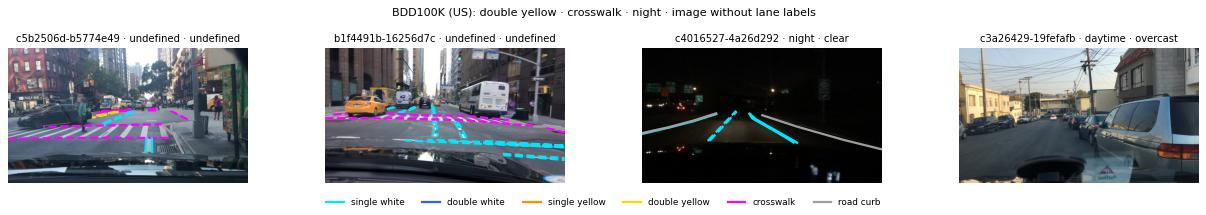

In [8]:
BDD_COLORS = {"single white": "#00e5ff", "double white": "#2962ff", "single yellow": "#ff9100", "double yellow": "#ffd600",
              "crosswalk": "#ff00ff", "road curb": "#9e9e9e"}

def show_bdd(ax, name):
    ax.imshow(Image.open(bdd_images[name]))
    for cat, style, v in BDD_LANES.get(name, []):
        if len(v) >= 2:
            xs, ys = zip(*v)
            ax.plot(xs, ys, color=BDD_COLORS.get(cat, "#76ff03"), lw=2, ls="--" if style == "dashed" else "-")
    row = bdd_frames.set_index("image").loc[name]
    ax.set_title(f"{name[:17]} · {row.timeofday} · {row.weather}"); ax.axis("off")

def pick(names, k=1):
    names = sorted(names)
    return random.sample(names, min(k, len(names)))

lab = bdd_lanes.groupby("image")["category"].apply(set)
examples = (pick([n for n, s in lab.items() if "double yellow" in s])
            + pick([n for n, s in lab.items() if "crosswalk" in s])
            + pick(bdd_frames.loc[bdd_frames.timeofday == "night", "image"])
            + pick(bdd_frames.loc[bdd_frames.n_lane_labels == 0, "image"]))
fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 2.6))
for ax, n in zip(np.atleast_1d(axes), examples):
    show_bdd(ax, n)
handles = [plt.Line2D([], [], color=c, lw=2, label=k) for k, c in BDD_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=8, frameon=False)
fig.suptitle("BDD100K (US): double yellow · crosswalk · night · image without lane labels", fontsize=10)
plt.tight_layout(rect=(0, 0.08, 1, 0.95)); plt.show()

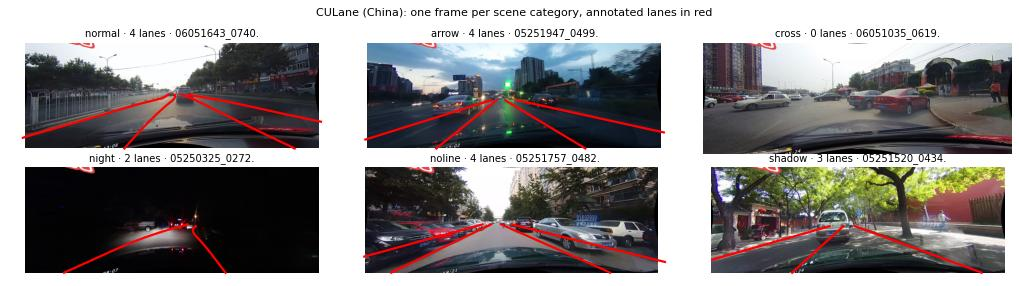

In [9]:
def show_culane(ax, frame):
    ax.imshow(Image.open(CU_ROOT / frame))
    for ln in CU_LANES.get(frame, []):
        xs, ys = zip(*ln)
        ax.plot(xs, ys, color="red", lw=2)
    row = cu_frames.set_index("frame").loc[frame]
    ax.set_title(f"{row.category} · {row.n_lanes} lanes · {frame.split('/')[1][:14]}"); ax.axis("off")

cats = [c for c in ["normal", "arrow", "cross", "night", "noline", "shadow"] if c in set(cu_frames.category)]
picks = [f for c in cats for f in pick(cu_frames.loc[(cu_frames.category == c) & cu_frames.image_exists, "frame"])]
fig, axes = plt.subplots(2, 3, figsize=(13, 3.6))
for ax, f in zip(axes.ravel(), picks):
    show_culane(ax, f)
for ax in axes.ravel()[len(picks):]:
    ax.axis("off")
fig.suptitle("CULane (China): one frame per scene category, annotated lanes in red", fontsize=10)
plt.tight_layout(); plt.show()

## 7 · Look while you are here: data checks

**Why:** before choosing images for the experiment, I need to know where the data is incomplete, unbalanced or repeated. The numbers below are the data-quality evidence for Section 6.4 of the plan. Problems without a fix are listed in Section 9.

### 7.1 Missing values, and where they cluster

Which images have no lane label at all, and whether these gaps are random or bunched in certain conditions (for example at night or at crossroads). Images without labels cannot be used to check the model's answers.

In [10]:
bdd_frames["has_lane_label"] = bdd_frames.n_lane_labels > 0
miss = (bdd_frames.groupby("timeofday", observed=True)["has_lane_label"]
        .agg(images="size", without_lane_labels=lambda s: int((~s).sum())))
miss["share_without"] = (miss.without_lane_labels / miss.images).round(3)
display(Markdown("**BDD100K: images without any lane label, by time of day**")); display(miss)
undefined = {c: int((bdd_frames[c].astype(str).isin(["undefined", "missing"])).sum()) for c in ("weather", "timeofday", "scene")}
print("BDD100K scene tags that are 'undefined' or missing:", undefined)

cu_miss = pd.DataFrame({
    "frames": cu_frames.groupby("category", observed=True).size(),
    "image_missing": cu_frames.groupby("category", observed=True)["image_exists"].apply(lambda s: int((~s).sum())),
    "annotation_missing": cu_frames.groupby("category", observed=True)["annotation_exists"].apply(lambda s: int((~s).sum())),
    "zero_lanes": cu_frames.groupby("category", observed=True)["n_lanes"].apply(lambda s: int((s == 0).sum())),
})
cu_miss["share_zero_lanes"] = (cu_miss.zero_lanes / cu_miss.frames).round(3)
display(Markdown("**CULane: missing files and frames with no annotated lane, by category**")); display(cu_miss)

**BDD100K: images without any lane label, by time of day**

,images,without_lane_labels,share_without
timeofday,,,
dawn/dusk,712,26,0.037
daytime,4260,143,0.034
night,3829,226,0.059
undefined,1199,79,0.066


BDD100K scene tags that are 'undefined' or missing: {'weather': 1157, 'timeofday': 1199, 'scene': 1199}


**CULane: missing files and frames with no annotated lane, by category**

,frames,image_missing,annotation_missing,zero_lanes,share_zero_lanes
category,,,,,
arrow,890,0,0,0,0.000
cross,3122,0,0,3122,1.000
crowd,8113,0,0,4,0.000
curve,422,0,0,0,0.000
hlight,486,0,0,6,0.012
night,7029,0,0,763,0.109
noline,4067,0,0,3,0.001
normal,9621,0,0,0,0.000
shadow,930,0,0,29,0.031


### 7.2 Class balance and coverage of my four core marking types

How many labels each marking category has, and how many candidate images exist for each of the four core types (solid white, dashed white, yellow centre line, turn-guide arrow). A rare type limits how many test images I can pick.

In [11]:
display(Markdown("**BDD100K lane categories** (labels and images)"))
cat_tab = pd.DataFrame({"labels": bdd_lanes.category.value_counts(),
                        "images": bdd_lanes.groupby("category")["image"].nunique()}).sort_values("images", ascending=False)
display(cat_tab)
display(Markdown("**BDD100K images per lane category × time of day**"))
display(pd.crosstab(bdd_lanes.drop_duplicates(["image", "category"]).category,
                    bdd_lanes.drop_duplicates(["image", "category"]).image.map(bdd_frames.set_index("image").timeofday)))

# category sizes from the CULane paper, to check the download is complete
PUBLISHED = {"normal": 9621, "crowd": 8113, "hlight": 486, "shadow": 930, "noline": 4067,
             "arrow": 890, "curve": 422, "cross": 3122, "night": 7029}
cu_bal = cu_frames.category.value_counts().rename("frames_here").to_frame()
cu_bal["published"] = cu_bal.index.map(PUBLISHED)
display(Markdown("**CULane test categories: here vs. published**")); display(cu_bal)
display(Markdown("**CULane frames per archive × category**")); display(pd.crosstab(cu_frames.archive, cu_frames.category))

# candidates for the four core marking types
par = bdd_lanes[bdd_lanes.direction == "parallel"]
def n_img(mask): return int(par[mask].image.nunique())
coverage = pd.DataFrame([
    ["solid line",          n_img(par["style"] == "solid"),  "BDD laneStyle = solid",
     int((cu_frames.n_lanes > 0).sum()), "lane positions only; type checked by eye"],
    ["dashed line",         n_img(par["style"] == "dashed"), "BDD laneStyle = dashed",
     int((cu_frames.n_lanes > 0).sum()), "lane positions only; type checked by eye"],
    ["yellow centre line",  n_img(par.category.isin(["single yellow", "double yellow"])), "BDD single/double yellow",
     int((cu_frames.n_lanes > 0).sum()), "colour not labelled; checked by eye"],
    ["turn-guide arrow",    0, "not labelled; search city streets with crosswalks by eye",
     int((cu_frames.category == "arrow").sum()), "CULane 'arrow' category"],
], columns=["marking type", "US candidate images", "US source of candidates", "CN candidate frames", "CN source of candidates"])
display(Markdown("**Coverage of the four core marking types (candidates before manual checking)**")); display(coverage)

**BDD100K lane categories** (labels and images)

,labels,images
category,,
road curb,15822,8069
single white,35452,7428
crosswalk,15341,3625
double yellow,5426,2152
single yellow,2817,1407
double white,831,372
single other,40,14
double other,1,1


**BDD100K images per lane category × time of day**

image,dawn/dusk,daytime,night,undefined
category,,,,
crosswalk,238,1475,1411,501
double other,0,0,1,0
double white,25,142,157,48
double yellow,171,985,767,229
road curb,601,3582,2903,983
single other,0,8,3,3
single white,561,3235,2824,808
single yellow,126,854,282,145


**CULane test categories: here vs. published**

,frames_here,published
category,,
normal,9621,9621
crowd,8113,8113
night,7029,7029
noline,4067,4067
cross,3122,3122
shadow,930,930
arrow,890,890
hlight,486,486
curve,422,422


**CULane frames per archive × category**

category,arrow,cross,crowd,curve,hlight,night,noline,normal,shadow
archive,,,,,,,,,
driver_100_30frame,309,1118,3330,272,155,6251,1488,4069,710
driver_193_90frame,445,1483,3465,139,39,598,2263,4985,204
driver_37_30frame,136,521,1318,11,292,180,316,567,16


**Coverage of the four core marking types (candidates before manual checking)**

,marking type,US candidate images,US source of candidates,CN candidate frames,CN source of candidates
0,solid line,9145,BDD laneStyle = solid,30753,lane positions only; type checked by eye
1,dashed line,5306,BDD laneStyle = dashed,30753,lane positions only; type checked by eye
2,yellow centre line,3476,BDD single/double yellow,30753,colour not labelled; checked by eye
3,turn-guide arrow,0,not labelled; search city streets with crosswa...,890,CULane 'arrow' category


### 7.3 Duplicates and near-duplicates

Exact copies are found by file hash; near-duplicates by a small perceptual hash (dHash). CULane frames come from video, so consecutive frames look almost the same. If both ended up in the test set, one scene would be counted twice.

CULane: 270 pairs of consecutive frames in 8 clips; median distance 10/64 bits; 57% of pairs are within 10 bits (near-duplicates)
CULane: 419 clips; frames per clip median 58
BDD100K: 1 near-duplicate pairs (≤4 bits) among 1,000 sampled images; 0 exact duplicate files among 500


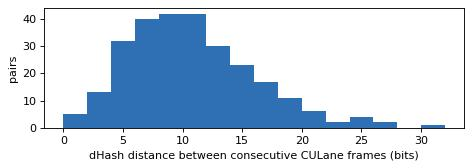

In [12]:
def dhash(path, size=8):
    """64-bit difference hash; similar images give similar bits."""
    g = np.asarray(Image.open(path).convert("L").resize((size + 1, size)), dtype=np.int16)
    return np.packbits((g[:, 1:] > g[:, :-1]).ravel())

def hamming(a, b):
    return int(np.unpackbits(a ^ b).sum())

# CULane: consecutive frames inside the same clip
clips = cu_frames[cu_frames.image_exists].groupby("clip")["frame"].apply(sorted)
clips = clips[clips.map(len) >= 10]
sample_clips = clips.sample(min(8, len(clips)), random_state=SEED)
dists = []
for frames in sample_clips:
    hs = [dhash(CU_ROOT / f) for f in frames[:40]]
    dists += [hamming(a, b) for a, b in zip(hs, hs[1:])]
dists = np.array(dists)
print(f"CULane: {len(dists)} pairs of consecutive frames in {len(sample_clips)} clips; "
      f"median distance {np.median(dists):.0f}/64 bits; {np.mean(dists <= 10):.0%} of pairs are within 10 bits (near-duplicates)")
print(f"CULane: {cu_frames['clip'].nunique():,} clips; frames per clip median {cu_frames.groupby('clip').size().median():.0f}")

# BDD100K: exact file duplicates and near-duplicates in a random sample of 1,000 images
sample = bdd_frames.sample(min(1000, len(bdd_frames)), random_state=SEED)
H = np.stack([dhash(p) for p in sample.path])
bits = np.unpackbits(H, axis=1).astype(np.uint8)
D = (bits[:, None, :] != bits[None, :, :]).sum(axis=2)
iu = np.triu_indices(len(D), k=1)
near = int((D[iu] <= 4).sum())
md5s = Counter(md5_of(p) for p in sample.path[:500])
print(f"BDD100K: {near} near-duplicate pairs (≤4 bits) among {len(sample):,} sampled images; "
      f"{sum(c - 1 for c in md5s.values())} exact duplicate files among 500")
fig, ax = plt.subplots(figsize=(6, 2.2))
ax.hist(dists, bins=range(0, 34, 2), color="#2f6fb3"); ax.set_xlabel("dHash distance between consecutive CULane frames (bits)")
ax.set_ylabel("pairs"); plt.tight_layout(); plt.show()

### 7.4 Unexpected ranges, sizes and formats

Image sizes, file formats and unreadable files on a sample, and lane coordinates that fall outside the image. These would break the drawing code or mislead the model.

In [13]:
def image_check(paths, n=300):
    sizes, modes, broken = Counter(), Counter(), 0
    for p in random.sample(list(paths), min(n, len(paths))):
        try:
            with Image.open(p) as im:
                sizes[im.size] += 1; modes[im.mode] += 1
                im.verify()
        except Exception:
            broken += 1
    return sizes, modes, broken

for name, paths, expected in [("BDD100K", bdd_frames.path, (1280, 720)),
                              ("CULane", cu_frames.loc[cu_frames.image_exists, "path"], (1640, 590))]:
    sizes, modes, broken = image_check(paths)
    print(f"{name}: sizes {dict(sizes)} | colour modes {dict(modes)} | unreadable {broken} | expected {expected}")

W, Hh = 1280, 720
out_bdd = bdd_lanes[(bdd_lanes.x_min < 0) | (bdd_lanes.x_max > W) | (bdd_lanes.y_min < 0) | (bdd_lanes.y_max > Hh)]
W2, H2 = 1640, 590
out_cu = cu_frames[(cu_frames.x_min < 0) | (cu_frames.x_max > W2) | (cu_frames.y_min < 0) | (cu_frames.y_max > H2)]
print(f"BDD100K lane labels with points outside the image: {len(out_bdd):,} of {len(bdd_lanes):,}")
print(f"CULane frames with lane points outside the image : {len(out_cu):,} of {len(cu_frames):,}")
print("Dates: CULane and BDD100K were published in 2017–2018, before MUTCD 11th Ed. (Dec 2023) and GB 5768.3-2025,"
      " so the roads in the images follow the older editions of both standards.")

BDD100K: sizes {(1280, 720): 300} | colour modes {'RGB': 300} | unreadable 0 | expected (1280, 720)
CULane: sizes {(1640, 590): 300} | colour modes {'RGB': 300} | unreadable 0 | expected (1640, 590)
BDD100K lane labels with points outside the image: 0 of 75,730
CULane frames with lane points outside the image : 26,921 of 34,680
Dates: CULane and BDD100K were published in 2017–2018, before MUTCD 11th Ed. (Dec 2023) and GB 5768.3-2025, so the roads in the images follow the older editions of both standards.


### 7.5 Does the data cover the conditions the system will meet?

Scene tags show which conditions exist. The two contact sheets below are for **manual search**: turn-guide arrows have no label in BDD100K, and CULane only groups them into its 'arrow' category, so they are counted by eye.
The counts go into `MANUAL_TALLY` and are used in Section 9.

**BDD100K conditions** (images)

images
timeofday daytime          4260
          night            3829
          undefined        1199
          dawn/dusk         712
weather   clear            5346
          overcast         1239
          undefined        1157
          snowy             769
          partly cloudy     738
          rainy             738
          foggy              13
scene     city street      5315
          highway          2367
          undefined        1199
          residential      1071
          parking lot        39
          gas stations        6
          tunnel              3

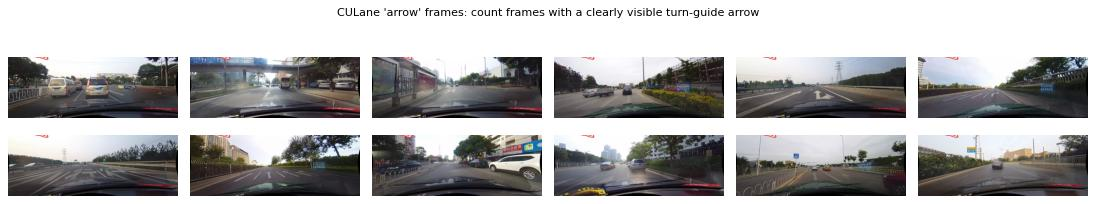

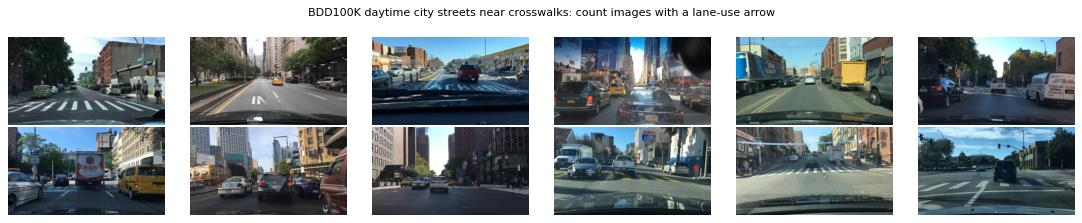

,CN_checked,CN_found,US_checked,US_found
turn-guide arrow,None,None,None,None


In [14]:
display(Markdown("**BDD100K conditions** (images)"))
display(pd.concat({c: bdd_frames[c].value_counts() for c in ("timeofday", "weather", "scene")}, axis=0).rename("images").to_frame())

def contact_sheet(paths, title, cols=6):
    paths = list(paths)
    rows = int(np.ceil(len(paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.3 * cols, 1.2 * rows + 0.4))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, p in zip(np.atleast_1d(axes).ravel(), paths):
        im = Image.open(p); im.thumbnail((400, 400)); ax.imshow(im)
    fig.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()

arrow_cn = cu_frames[(cu_frames.category == "arrow") & cu_frames.image_exists]
contact_sheet(arrow_cn.sample(min(12, len(arrow_cn)), random_state=SEED).path,
              "CULane 'arrow' frames: count frames with a clearly visible turn-guide arrow")
# US: daytime city streets with a crosswalk label (close to an intersection)
near_x = set(bdd_lanes.loc[bdd_lanes.category == "crosswalk", "image"])
city = bdd_frames[(bdd_frames.scene == "city street") & (bdd_frames.timeofday == "daytime") & bdd_frames.image.isin(near_x)]
contact_sheet(city.sample(min(12, len(city)), random_state=SEED).path,
              "BDD100K daytime city streets near crosswalks: count images with a lane-use arrow")

# filled in by hand after looking through the images above
MANUAL_TALLY = {
    "turn-guide arrow": {"CN_checked": None, "CN_found": None, "US_checked": None, "US_found": None},
}
display(pd.DataFrame(MANUAL_TALLY).T)

## 8 · Rule corpus (the text the model will cite)

The rule corpus is the text the model will cite: two standards, their size, and an excerpt.
`rules/rule_passages.json` holds the short passages that will be put into the prompt (rule ID, region, section, page, marking type, English text and the Chinese original).

In [15]:
from pypdf import PdfReader

def pdf_overview(path, keywords, excerpt_key):
    reader = PdfReader(str(path))
    pages = [(i + 1, (p.extract_text() or "")) for i, p in enumerate(reader.pages)]
    hits = {k: [n for n, t in pages if k.lower() in t.lower()] for k in keywords}
    print(f"{Path(path).name}: {len(pages)} pages")
    for k, ns in hits.items():
        print(f"  '{k}' appears on {len(ns)} pages, e.g. {ns[:6]}")
    for n, t in pages:
        i = t.lower().find(excerpt_key.lower())
        if i >= 0:
            snippet = " ".join(t[max(0, i - 200): i + 400].split())
            display(Markdown(f"**Excerpt, page {n}:**\n\n> {snippet}"))
            break

pdf_overview(MUTCD_PDF, ["broken line", "solid line", "yellow", "Do Not Block"], "broken line")
if GB_PDF.exists():
    pdf_overview(GB_PDF, ["实线", "虚线", "黄色", "导向箭头"], "实线:表示")

passages = json.loads((REPO / "rules" / "rule_passages.json").read_text(encoding="utf-8"))
print(f"\nCurated passages in rules/rule_passages.json: {len(passages)}")
if passages:
    display(pd.DataFrame(passages).head())
else:
    print("Not written yet. Format of one entry:")
    print(json.dumps({"rule_id": "US-MUTCD-3x.xx-1", "region": "US", "source": "MUTCD 11th Ed.", "section": "3x.xx",
                      "page": 0, "marking_type": "dashed line", "text_en": "<short quoted passage>", "text_zh": None},
                     indent=2, ensure_ascii=False))

MUTCD_11th_Part3_Markings.pdf: 106 pages
  'broken line' appears on 6 pages, e.g. [2, 4, 7, 32, 35, 36]
  'solid line' appears on 10 pages, e.g. [2, 4, 7, 27, 35, 36]
  'yellow' appears on 32 pages, e.g. [1, 4, 5, 6, 7, 9]
  'Do Not Block' appears on 2 pages, e.g. [45, 47]


**Excerpt, page 2:**

> of longitudinal lines shall be as follows: A. A double line indicates maximum or special restrictions. B. A solid line discourages or prohibits crossing (depending on the specific application). C. A broken line indicates a permissive condition. D. A dotted lane line provides warning of a downstream change in lane function. E. A dotted line used as a lane line or edge line extension guides vehicles through an intersection, a taper area, or an interchange ramp area. 02 The widths and patterns of longitudinal lines shall be as follows: A. Normal line—4 to 6 inches wide. B. Wide line—at least t

GB_5768.3-2025.pdf: 123 pages
  '实线' appears on 33 pages, e.g. [6, 9, 10, 12, 13, 14]
  '虚线' appears on 30 pages, e.g. [5, 9, 10, 11, 12, 13]
  '黄色' appears on 17 pages, e.g. [5, 10, 12, 15, 43, 49]
  '导向箭头' appears on 13 pages, e.g. [3, 15, 35, 36, 37, 38]


**Excerpt, page 9:**

> .2 分类 4.2.1 道路交通标线按功能分为以下四类。 a) 指示标线:指示车道、行车方向、人行横道、停车位、停靠站及减速丘等的标线。 b) 禁止标线:表示道路交通的禁止、限制等的标线。 c) 警告标线:警示道路使用者注意道路上特殊情况的标线。 d) 其他标线:突起路标、轮廓标等。 4.2.2 道路交通标线按设置方式分为以下三类。 a) 纵向标线:沿道路行车方向设置的标线,按形式可分为: ———实线:表示正常情况下禁止跨越,紧急情况下确保安全时可跨越; ———虚线:表示可跨越; 1 GB5768.3—2025


Curated passages in rules/rule_passages.json: 26


,rule_id,region,source,section,page,marking_type,text_zh,text_en,text_en_is_translation
0,CN-4.2.2-a,CN,GB 5768.3-2025,4.2.2 a),1,solid line / dashed line (general),纵向标线：沿道路行车方向设置的标线，按形式可分为：———实线：表示正常情况下禁止跨越，紧急情...,"Longitudinal markings, set along the direction...",True
1,CN-4.3.2,CN,GB 5768.3-2025,4.3.2 a) b),2,yellow centre line / white lane line (colour),白色纵向标线：分隔同向行驶的交通流；指示行车方向右侧边缘。黄色纵向标线：分隔对向行驶的交通流...,White longitudinal markings separate traffic f...,True
2,CN-5.1.1,CN,GB 5768.3-2025,5.1.1,2,yellow centre line (broken),可跨越对向车行道分界线，也称为可跨越中心线，用以分隔对向行驶的交通流。……表示车辆在不影响安...,The crossable centre line separates traffic fl...,True
3,CN-5.1.2,CN,GB 5768.3-2025,5.1.2,2,yellow centre line (broken),可跨越对向车行道分界线为黄色虚线，线段长度4m、间隔6m（也称为“4-6线”）。,The crossable centre line is a broken yellow l...,True
4,CN-5.2.1-2,CN,GB 5768.3-2025,"5.2.1, 5.2.2",3,dashed line (white lane line),可跨越同向车行道分界线，用以分隔同向行驶的交通流，设在同向行驶的车行道分界上。可跨越同向车行...,The crossable lane line separates traffic flow...,True


## 9 · Findings and gaps (evidence for Section 6.4)

The main results of Sections 5–8 in one place, and what they mean for picking the test images.

In [16]:
night_share = miss.loc["night", "share_without"] if "night" in miss.index else float("nan")
day_share = miss.loc["daytime", "share_without"] if "daytime" in miss.index else float("nan")
complete = all(cu_bal.loc[c, "frames_here"] == PUBLISHED[c] for c in PUBLISHED if c in cu_bal.index) and len(cu_bal) >= 9
findings = [
    f"BDD100K: {int((~bdd_frames.has_lane_label).sum()):,} of {len(bdd_frames):,} validation images have no lane label "
    f"({day_share:.0%} of daytime vs {night_share:.0%} of night images).",
    f"BDD100K labels {bdd_lanes.category.nunique()} lane categories but no turn arrows, so US arrows are found by eye.",
    f"BDD100K has {int(bdd_lanes.loc[bdd_lanes.category == 'single yellow', 'image'].nunique()):,} images with a 'single yellow' line. "
    "MUTCD 3B.01 forbids a single solid yellow line as a two-way centre line, while GB 5768.3 6.1.4 allows it: the same marking "
    "means different things in the two regions.",
    f"CULane labels lane positions only (no colour, no solid/dashed). {int((cu_frames.n_lanes == 0).sum()):,} test frames have no annotated lane, "
    f"{int(cu_miss.loc['noline', 'zero_lanes']) if 'noline' in cu_miss.index else 0:,} of them in the 'no line' category.",
    f"CULane test categories {'match' if complete else 'do NOT match'} the published sizes (9 categories, 34,680 frames).",
    f"Consecutive CULane frames are near-duplicates ({np.mean(dists <= 10):.0%} of sampled pairs within 10 bits), "
    "so the dev/test split must be made by clip, not by frame.",
    "Both datasets predate the rule editions I give the model (MUTCD 11th Ed. 2023, GB 5768.3-2025).",
]
if BDD_SOURCE == "mirror":
    findings.insert(0, "The official BDD100K download server could not be reached (host name not resolvable), so BDD100K came from "
                       "the Dataset Ninja mirror of the same release. Reproducibility now depends on a third-party copy.")
for k, v in MANUAL_TALLY.items():
    if v["CN_checked"] is not None or v["US_checked"] is not None:
        findings.append(f"Manual search, {k}: China {v['CN_found']}/{v['CN_checked']} frames, US {v['US_found']}/{v['US_checked']} images.")
display(Markdown("\n".join(f"- {f}" for f in findings)))

- The official BDD100K download server could not be reached (host name not resolvable), so BDD100K came from the Dataset Ninja mirror of the same release. Reproducibility now depends on a third-party copy.
- BDD100K: 474 of 10,000 validation images have no lane label (3% of daytime vs 6% of night images).
- BDD100K labels 8 lane categories but no turn arrows, so US arrows are found by eye.
- BDD100K has 1,407 images with a 'single yellow' line. MUTCD 3B.01 forbids a single solid yellow line as a two-way centre line, while GB 5768.3 6.1.4 allows it: the same marking means different things in the two regions.
- CULane labels lane positions only (no colour, no solid/dashed). 3,927 test frames have no annotated lane, 3 of them in the 'no line' category.
- CULane test categories match the published sizes (9 categories, 34,680 frames).
- Consecutive CULane frames are near-duplicates (57% of sampled pairs within 10 bits), so the dev/test split must be made by clip, not by frame.
- Both datasets predate the rule editions I give the model (MUTCD 11th Ed. 2023, GB 5768.3-2025).

**Gaps I cannot fix (kept for Section 6.4)**

1. **Places:** China is Beijing only; the US is mostly New York and the San Francisco Bay Area. Other provinces, states and rural roads are missing, so results cannot be claimed for other regions.
2. **Time:** the images are older than the rule editions given to the model. I can flag marking types whose rule changed, but I cannot get newer images.
3. **Unlabelled markings:** turn arrows are not labelled in BDD100K; if fewer than 15 usable US images are found, more US images are added from another source (risk R3).
4. **Cameras and context:** only these dataset cameras, and single frames without video context.
5. **Translation:** the Chinese rule passages are translated and checked by one person (me).

## 10 · Changes since Milestone 2 (Sections 2.3–2.7)

| Item | Milestone 2 plan | Now | Effect |
|---|---|---|---|
| Marking types | Five (incl. no-stopping grid) | Four core types: solid white, dashed white, yellow centre line, turn-guide arrow | Grid dropped: rare in both datasets and not central to the cross-region question |
| Storage for data | MacBook Air internal disk, ~10 GB free | External SSD (T9, ~900 GB) attached to the same MacBook Air; the laptop runs all code | Disk is no longer a bottleneck (2.3, 2.6) |
| Download strategy | Download in parts, delete archives | Keep archives until the image selection is final | Re-extraction possible without new downloads |
| CULane part used | One test archive | Full test split (3 archives) | All 9 categories available for finding rare markings |
| Storage | Data stays local, no cloud | Unchanged: official servers + Git-ignored local copy | No re-upload, as the CULane license requires |
| Retrieval | Scripted downloads | BDD100K and MUTCD scripted; CULane and GB 5768.3 downloaded by hand (Google Drive limit; no direct link on the standards platform) | Two manual steps, both documented in Sections 2 and 3 |

The API, the budget ($50) and the rest of the design are unchanged.